# Latent Trajectory — Visual Experiments

> **Goal:** Treat a trajectory as a time-ordered geometric object with sampling, events, alignment, and support constraints—not merely a tensor of latent points.

## What we will explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Paths versus endpoints** | What information disappears when a trajectory is summarized by its final state? |
| 2 | **Irregular timestamps** | Why must velocity and resampling use physical time rather than array index? |
| 3 | **Smoothing trade-offs** | How can denoising erase or distort a meaningful event? |
| 4 | **Changepoint segmentation** | How does a complexity penalty trade under-segmentation against over-segmentation? |
| 5 | **Temporal alignment** | Why can two executions of the same path look different under pointwise comparison? |
| 6 | **Interpolation geometry** | Why can a straight latent chord leave the supported manifold? |

**Linked theory:** [Latent Trajectory](../research/06-latent-trajectory.md)

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})

def path_length(points):
    return np.sum(np.linalg.norm(np.diff(points, axis=0), axis=1))

def dynamic_time_warping(first, second):
    local_cost = np.linalg.norm(first[:, None, :] - second[None, :, :], axis=2)
    accumulated = np.full((len(first) + 1, len(second) + 1), np.inf)
    accumulated[0, 0] = 0.0
    parent = np.zeros((len(first), len(second), 2), dtype=int)

    for i in range(1, len(first) + 1):
        for j in range(1, len(second) + 1):
            candidates = [accumulated[i - 1, j], accumulated[i, j - 1], accumulated[i - 1, j - 1]]
            choice = int(np.argmin(candidates))
            accumulated[i, j] = local_cost[i - 1, j - 1] + candidates[choice]
            parent[i - 1, j - 1] = [(i - 2, j - 1), (i - 1, j - 2), (i - 2, j - 2)][choice]

    i, j = len(first) - 1, len(second) - 1
    path = []
    while i >= 0 and j >= 0:
        path.append((i, j))
        next_i, next_j = parent[i, j]
        if next_i == i and next_j == j:
            break
        i, j = next_i, next_j
    path.reverse()
    return local_cost, accumulated[1:, 1:], np.asarray(path), accumulated[-1, -1] / len(path)

---
## Experiment 1: The same endpoints can hide different histories

**Question:** What is lost if a sequence is represented only by its start and end latent states?

We construct three paths with identical endpoints: a direct transition, a smooth detour, and a loop. Their endpoint displacement is equal, but path length, tortuosity, visited regions, and motion direction differ.

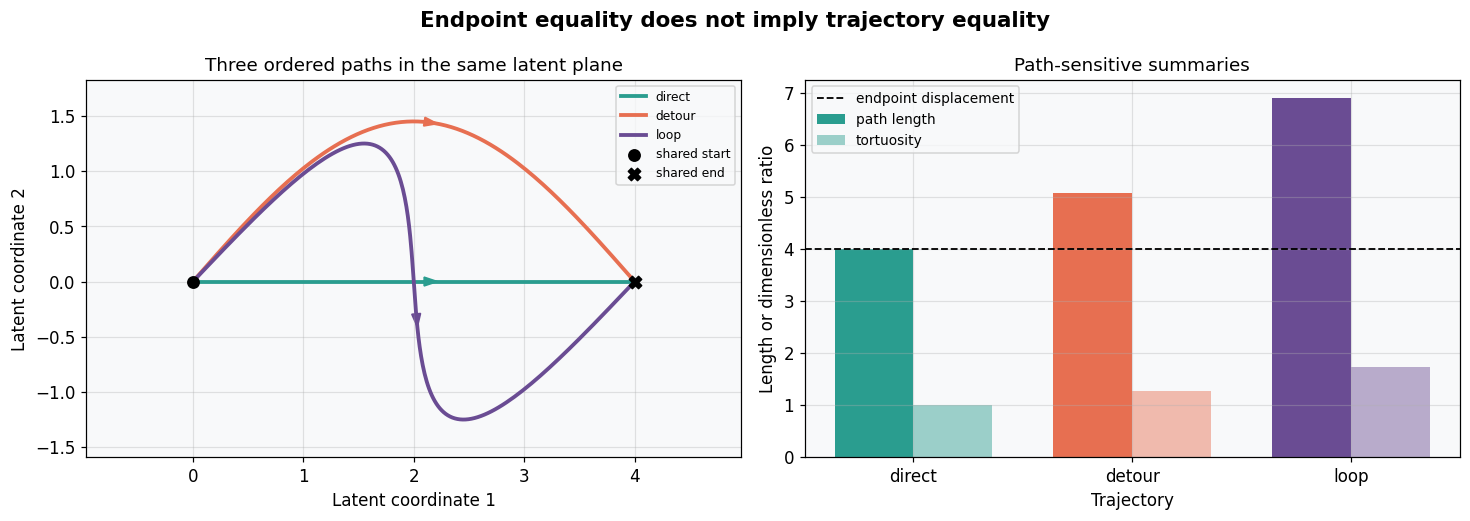

In [2]:
np.random.seed(1)
sample_count = 160
phase = np.linspace(0.0, 1.0, sample_count)
direct = np.column_stack([4.0 * phase, np.zeros_like(phase)])
detour = np.column_stack([4.0 * phase, 1.45 * np.sin(np.pi * phase)])
loop = np.column_stack([
    4.0 * phase + 0.55 * np.sin(2.0 * np.pi * phase),
    1.25 * np.sin(2.0 * np.pi * phase),
])
trajectories = {'direct': direct, 'detour': detour, 'loop': loop}
colors = {'direct': '#2a9d8f', 'detour': '#e76f51', 'loop': '#6a4c93'}
lengths = {name: path_length(points) for name, points in trajectories.items()}
displacement = np.linalg.norm(direct[-1] - direct[0])
tortuosities = {name: value / displacement for name, value in lengths.items()}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
fig.suptitle('Endpoint equality does not imply trajectory equality', fontsize=14, fontweight='bold')

for name, points in trajectories.items():
    axes[0].plot(points[:, 0], points[:, 1], color=colors[name], linewidth=2.5, label=name)
    arrow_index = 85
    delta = points[arrow_index + 3] - points[arrow_index]
    axes[0].arrow(points[arrow_index, 0], points[arrow_index, 1], delta[0], delta[1], color=colors[name], head_width=0.08, length_includes_head=True)
axes[0].scatter([direct[0, 0]], [direct[0, 1]], color='black', s=55, marker='o', zorder=4, label='shared start')
axes[0].scatter([direct[-1, 0]], [direct[-1, 1]], color='black', s=65, marker='X', zorder=4, label='shared end')
axes[0].set_title('Three ordered paths in the same latent plane')
axes[0].set_xlabel('Latent coordinate 1')
axes[0].set_ylabel('Latent coordinate 2')
axes[0].axis('equal')
axes[0].legend(fontsize=8)

names = list(trajectories)
axes[1].bar(np.arange(len(names)) - 0.18, [lengths[name] for name in names], 0.36, color=[colors[name] for name in names], label='path length')
axes[1].bar(np.arange(len(names)) + 0.18, [tortuosities[name] for name in names], 0.36, color=[colors[name] for name in names], alpha=0.45, label='tortuosity')
axes[1].axhline(displacement, color='black', linestyle='--', linewidth=1.2, label='endpoint displacement')
axes[1].set_xticks(np.arange(len(names)), names)
axes[1].set_title('Path-sensitive summaries')
axes[1].set_xlabel('Trajectory')
axes[1].set_ylabel('Length or dimensionless ratio')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** Every path begins and ends at the same latent states, yet the detour and loop travel farther and have larger tortuosity than the direct path.
2. **Why it looks this way:** Endpoints preserve net displacement but discard order, visited regions, direction, and accumulated motion. These properties live in the sequence between the endpoints.
3. **Key takeaway:** A trajectory primitive must retain temporal order and timestamps; start/end pooling cannot support event analysis, dynamics diagnostics, or path retrieval.

---
## Experiment 2: Array index is not physical time

**Question:** How do irregular timestamps affect velocity estimation and resampling?

We sample a smooth latent curve at uneven intervals. One derivative assumes every adjacent pair has the median time gap; the other uses the actual timestamps.

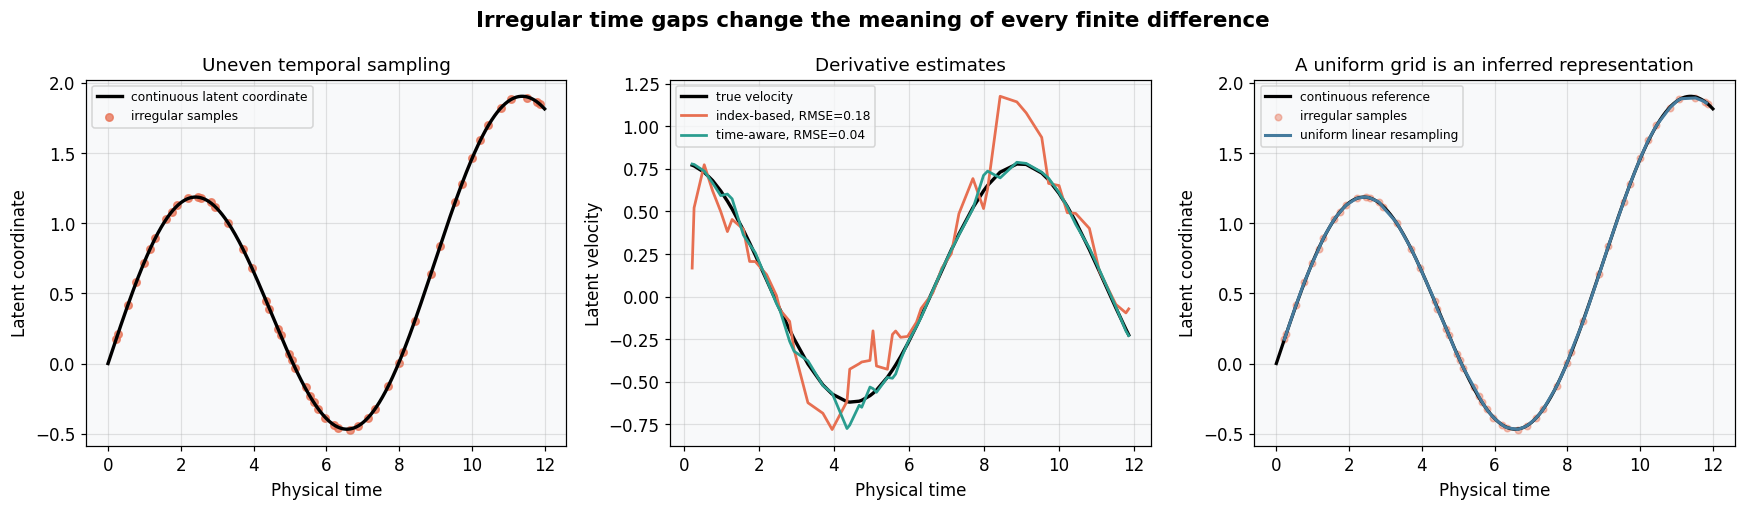

In [3]:
np.random.seed(2)
dense_time = np.linspace(0.0, 12.0, 1000)
true_position = np.sin(0.7 * dense_time) + 0.08 * dense_time
true_velocity = 0.7 * np.cos(0.7 * dense_time) + 0.08

gaps = np.random.uniform(0.04, 0.46, size=90)
sample_time = np.cumsum(gaps)
sample_time = sample_time[sample_time <= dense_time[-1]]
sample_position = np.sin(0.7 * sample_time) + 0.08 * sample_time + 0.004 * np.random.randn(len(sample_time))
sample_true_velocity = 0.7 * np.cos(0.7 * sample_time) + 0.08
median_gap = np.median(np.diff(sample_time))
index_velocity = np.gradient(sample_position) / median_gap
time_aware_velocity = np.gradient(sample_position, sample_time)

uniform_time = np.arange(sample_time[0], sample_time[-1], 0.10)
uniform_position = np.interp(uniform_time, sample_time, sample_position)
index_error = np.sqrt(np.mean((index_velocity - sample_true_velocity) ** 2))
time_aware_error = np.sqrt(np.mean((time_aware_velocity - sample_true_velocity) ** 2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.7))
fig.suptitle('Irregular time gaps change the meaning of every finite difference', fontsize=14, fontweight='bold')

axes[0].plot(dense_time, true_position, color='black', linewidth=2.2, label='continuous latent coordinate')
axes[0].scatter(sample_time, sample_position, color='#e76f51', s=24, alpha=0.75, label='irregular samples')
axes[0].set_title('Uneven temporal sampling')
axes[0].set_xlabel('Physical time')
axes[0].set_ylabel('Latent coordinate')
axes[0].legend(fontsize=8)

axes[1].plot(sample_time, sample_true_velocity, color='black', linewidth=2.2, label='true velocity')
axes[1].plot(sample_time, index_velocity, color='#e76f51', linewidth=1.8, label=f'index-based, RMSE={index_error:.2f}')
axes[1].plot(sample_time, time_aware_velocity, color='#2a9d8f', linewidth=1.8, label=f'time-aware, RMSE={time_aware_error:.2f}')
axes[1].set_title('Derivative estimates')
axes[1].set_xlabel('Physical time')
axes[1].set_ylabel('Latent velocity')
axes[1].legend(fontsize=8)

axes[2].plot(dense_time, true_position, color='black', linewidth=2.1, label='continuous reference')
axes[2].scatter(sample_time, sample_position, color='#e76f51', s=18, alpha=0.42, label='irregular samples')
axes[2].plot(uniform_time, uniform_position, color='#457b9d', linewidth=2.0, label='uniform linear resampling')
axes[2].set_title('A uniform grid is an inferred representation')
axes[2].set_xlabel('Physical time')
axes[2].set_ylabel('Latent coordinate')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** Treating every index gap as equal creates velocity spikes and larger error. Using real timestamps tracks the derivative better, while linear resampling fills a regular grid without creating new observations.
2. **Why it looks this way:** Displacement depends on both velocity and elapsed time. An array index carries order but not duration, so finite differences in index space mix slow motion with long sampling gaps.
3. **Key takeaway:** Timestamps, masks, and interpolation provenance are part of trajectory semantics. Resampled points should remain distinguishable from measured or posterior-corrected states.

---
## Experiment 3: Smoothing can erase a real event

**Question:** How do moving-average and local-polynomial smoothing trade noise reduction against event preservation?

A two-dimensional latent path contains a genuine abrupt mode switch. Noise makes the raw path jagged, but a smoother that assumes continuity can turn the switch into a gradual transition or overshoot around it.

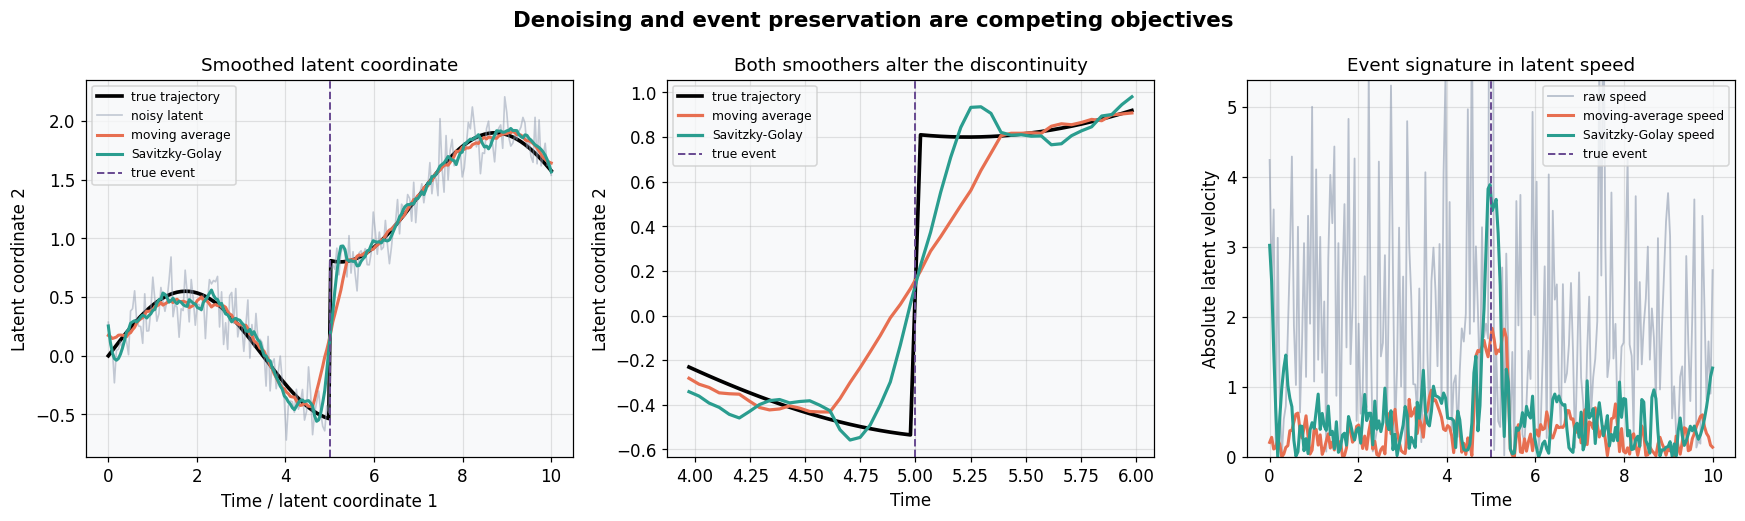

In [4]:
np.random.seed(3)
smooth_time = np.linspace(0.0, 10.0, 220)
event_time = 5.0
true_curve = np.column_stack([
    smooth_time,
    0.55 * np.sin(0.9 * smooth_time) + 1.35 * (smooth_time >= event_time),
])
noisy_curve = true_curve + np.column_stack([
    np.zeros_like(smooth_time),
    0.16 * np.random.randn(len(smooth_time)),
])

window = 17
kernel = np.ones(window) / window
moving_y = np.convolve(np.pad(noisy_curve[:, 1], window // 2, mode='edge'), kernel, mode='valid')
savgol_y = savgol_filter(noisy_curve[:, 1], window_length=17, polyorder=3, mode='interp')
moving_curve = np.column_stack([smooth_time, moving_y])
savgol_curve = np.column_stack([smooth_time, savgol_y])

raw_speed = np.abs(np.gradient(noisy_curve[:, 1], smooth_time))
moving_speed = np.abs(np.gradient(moving_y, smooth_time))
savgol_speed = np.abs(np.gradient(savgol_y, smooth_time))
event_index = np.argmin(np.abs(smooth_time - event_time))
quiet_mask = np.abs(smooth_time - event_time) > 0.8
quiet_rmse = {
    'raw': np.sqrt(np.mean((noisy_curve[quiet_mask, 1] - true_curve[quiet_mask, 1]) ** 2)),
    'moving average': np.sqrt(np.mean((moving_y[quiet_mask] - true_curve[quiet_mask, 1]) ** 2)),
    'Savitzky-Golay': np.sqrt(np.mean((savgol_y[quiet_mask] - true_curve[quiet_mask, 1]) ** 2)),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
fig.suptitle('Denoising and event preservation are competing objectives', fontsize=14, fontweight='bold')

axes[0].plot(true_curve[:, 0], true_curve[:, 1], color='black', linewidth=2.4, label='true trajectory')
axes[0].plot(noisy_curve[:, 0], noisy_curve[:, 1], color='#8d99ae', alpha=0.5, linewidth=1.1, label='noisy latent')
axes[0].plot(moving_curve[:, 0], moving_curve[:, 1], color='#e76f51', linewidth=2.0, label='moving average')
axes[0].plot(savgol_curve[:, 0], savgol_curve[:, 1], color='#2a9d8f', linewidth=2.0, label='Savitzky-Golay')
axes[0].axvline(event_time, color='#6a4c93', linestyle='--', linewidth=1.3, label='true event')
axes[0].set_title('Smoothed latent coordinate')
axes[0].set_xlabel('Time / latent coordinate 1')
axes[0].set_ylabel('Latent coordinate 2')
axes[0].legend(fontsize=8)

event_slice = slice(event_index - 22, event_index + 23)
axes[1].plot(smooth_time[event_slice], true_curve[event_slice, 1], color='black', linewidth=2.4, label='true trajectory')
axes[1].plot(smooth_time[event_slice], moving_y[event_slice], color='#e76f51', linewidth=2.1, label='moving average')
axes[1].plot(smooth_time[event_slice], savgol_y[event_slice], color='#2a9d8f', linewidth=2.1, label='Savitzky-Golay')
axes[1].axvline(event_time, color='#6a4c93', linestyle='--', linewidth=1.3, label='true event')
axes[1].set_title('Both smoothers alter the discontinuity')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Latent coordinate 2')
axes[1].legend(fontsize=8)

axes[2].plot(smooth_time, raw_speed, color='#8d99ae', alpha=0.6, linewidth=1.2, label='raw speed')
axes[2].plot(smooth_time, moving_speed, color='#e76f51', linewidth=2.0, label='moving-average speed')
axes[2].plot(smooth_time, savgol_speed, color='#2a9d8f', linewidth=2.0, label='Savitzky-Golay speed')
axes[2].axvline(event_time, color='#6a4c93', linestyle='--', linewidth=1.3, label='true event')
axes[2].set_title('Event signature in latent speed')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Absolute latent velocity')
axes[2].set_ylim(0.0, np.percentile(raw_speed, 97))
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** Both smoothers reduce noise in quiet regions, but the moving average spreads the jump across a window and Savitzky-Golay introduces local ringing around the discontinuity. Their speed peaks no longer match the original instantaneous event.
2. **Why it looks this way:** Each method assumes nearby samples belong to one smooth local trend. A real mode switch violates that assumption, so reducing variance necessarily biases the event shape.
3. **Key takeaway:** Segment or mark discontinuities before smoothing, and record whether a result used future samples. A visually clean trajectory can be less physically or causally correct.

---
## Experiment 4: Segmentation is a fit-versus-complexity decision

**Question:** How does a changepoint penalty determine whether a trajectory is split into meaningful regimes or noise fragments?

We generate a latent velocity signal with four regimes, then minimize within-segment squared error plus a penalty per segment using exact dynamic programming.

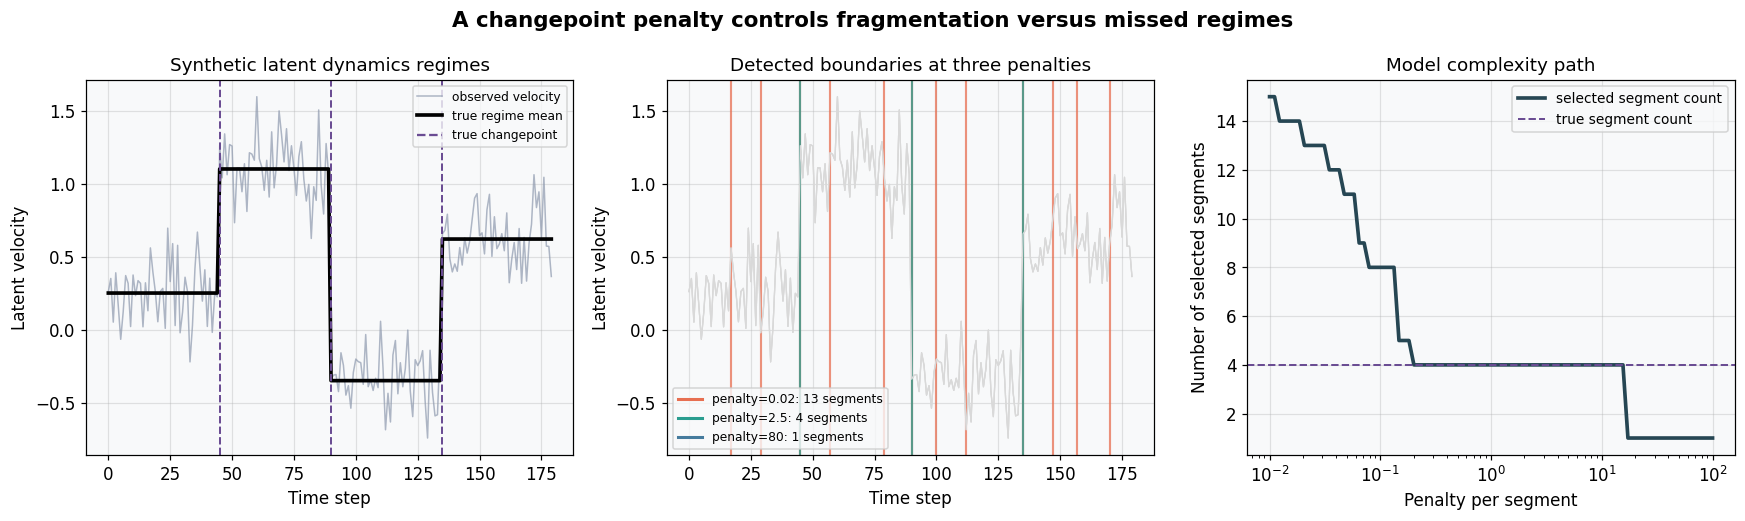

In [5]:
np.random.seed(4)
segment_length = 45
true_levels = np.repeat([0.25, 1.10, -0.35, 0.62], segment_length)
segment_time = np.arange(len(true_levels))
observed_levels = true_levels + 0.20 * np.random.randn(len(true_levels))
true_boundaries = np.array([segment_length, 2 * segment_length, 3 * segment_length])

prefix = np.concatenate([[0.0], np.cumsum(observed_levels)])
prefix_sq = np.concatenate([[0.0], np.cumsum(observed_levels**2)])

def segment_cost(start, end):
    count = end - start
    total = prefix[end] - prefix[start]
    total_sq = prefix_sq[end] - prefix_sq[start]
    return total_sq - total**2 / count

def penalized_segmentation(penalty, min_length=10):
    length = len(observed_levels)
    objective = np.full(length + 1, np.inf)
    previous = np.full(length + 1, -1, dtype=int)
    objective[0] = -penalty
    for end in range(min_length, length + 1):
        for start in range(0, end - min_length + 1):
            if start > 0 and previous[start] < 0:
                continue
            candidate = objective[start] + segment_cost(start, end) + penalty
            if candidate < objective[end]:
                objective[end] = candidate
                previous[end] = start
    boundaries = []
    end = length
    while end > 0:
        start = previous[end]
        if start > 0:
            boundaries.append(start)
        end = start
    return np.asarray(boundaries[::-1]), objective[length]

penalties = np.logspace(-2.0, 2.0, 90)
segment_counts = []
boundary_sets = []
for penalty in penalties:
    boundaries, _ = penalized_segmentation(penalty)
    boundary_sets.append(boundaries)
    segment_counts.append(len(boundaries) + 1)

chosen_penalties = [0.02, 2.5, 80.0]
chosen_results = {penalty: penalized_segmentation(penalty)[0] for penalty in chosen_penalties}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
fig.suptitle('A changepoint penalty controls fragmentation versus missed regimes', fontsize=14, fontweight='bold')

axes[0].plot(segment_time, observed_levels, color='#8d99ae', linewidth=1.0, alpha=0.7, label='observed velocity')
axes[0].plot(segment_time, true_levels, color='black', linewidth=2.4, label='true regime mean')
for boundary in true_boundaries:
    axes[0].axvline(boundary, color='#6a4c93', linestyle='--', linewidth=1.3)
axes[0].plot([], [], color='#6a4c93', linestyle='--', label='true changepoint')
axes[0].set_title('Synthetic latent dynamics regimes')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Latent velocity')
axes[0].legend(fontsize=8)

penalty_colors = ['#e76f51', '#2a9d8f', '#457b9d']
for penalty, color in zip(chosen_penalties, penalty_colors):
    axes[1].plot(segment_time, observed_levels, color='#d9d9d9', linewidth=0.8)
    boundaries = chosen_results[penalty]
    for boundary in boundaries:
        axes[1].axvline(boundary, color=color, alpha=0.75, linewidth=1.4)
    axes[1].plot([], [], color=color, linewidth=2.0, label=f'penalty={penalty:g}: {len(boundaries)+1} segments')
axes[1].set_title('Detected boundaries at three penalties')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Latent velocity')
axes[1].legend(fontsize=8)

axes[2].plot(penalties, segment_counts, color='#264653', linewidth=2.4, label='selected segment count')
axes[2].axhline(4, color='#6a4c93', linestyle='--', linewidth=1.3, label='true segment count')
axes[2].set_title('Model complexity path')
axes[2].set_xlabel('Penalty per segment')
axes[2].set_ylabel('Number of selected segments')
axes[2].set_xscale('log')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** A small penalty creates many noise-driven segments, an intermediate penalty recovers the four regimes, and a large penalty merges real changes. Segment count decreases in discrete steps as complexity becomes more expensive.
2. **Why it looks this way:** Within-segment error always improves when more boundaries are allowed. The penalty is the counterforce that asks whether each extra split explains enough structure to justify another regime.
3. **Key takeaway:** Segmentation has no scale-free default. Penalties and local costs must be calibrated to latent normalization, noise level, duration, and the events the application cares about.

---
## Experiment 5: Alignment separates path shape from execution speed

**Question:** Why does pointwise distance over-penalize two trajectories that traverse the same path at different speeds?

Both trajectories follow the same curved route. One moves at uniform phase speed; the other spends more samples near the beginning and then catches up.

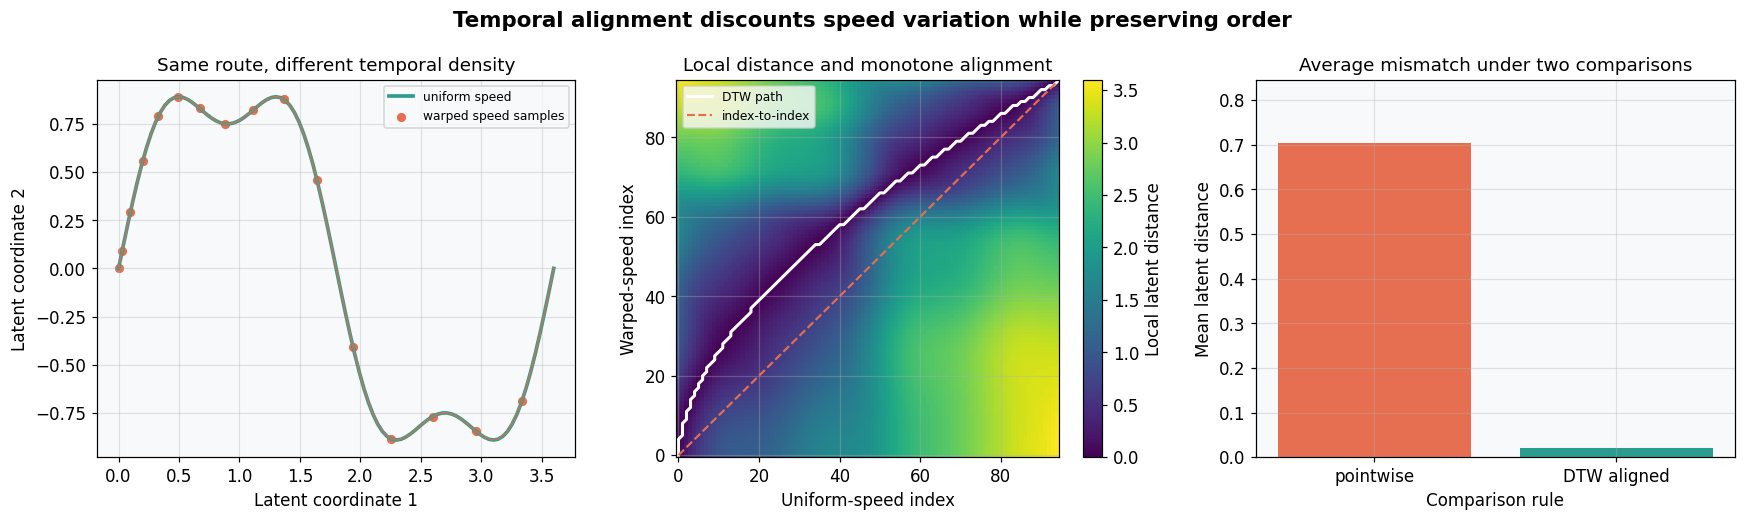

In [6]:
np.random.seed(5)
alignment_count = 95
uniform_phase = np.linspace(0.0, 1.0, alignment_count)
warped_phase = np.linspace(0.0, 1.0, alignment_count) ** 1.75

def route(phase_values):
    return np.column_stack([
        3.6 * phase_values,
        np.sin(2.0 * np.pi * phase_values) + 0.25 * np.sin(6.0 * np.pi * phase_values),
    ])

first_path = route(uniform_phase)
second_path = route(warped_phase)
local_cost, accumulated_cost, warping_path, dtw_mean_cost = dynamic_time_warping(first_path, second_path)
pointwise_mean_cost = np.mean(np.linalg.norm(first_path - second_path, axis=1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
fig.suptitle('Temporal alignment discounts speed variation while preserving order', fontsize=14, fontweight='bold')

axes[0].plot(first_path[:, 0], first_path[:, 1], color='#2a9d8f', linewidth=2.4, label='uniform speed')
axes[0].scatter(second_path[::6, 0], second_path[::6, 1], color='#e76f51', s=25, label='warped speed samples')
axes[0].plot(second_path[:, 0], second_path[:, 1], color='#e76f51', linewidth=1.4, alpha=0.65)
axes[0].set_title('Same route, different temporal density')
axes[0].set_xlabel('Latent coordinate 1')
axes[0].set_ylabel('Latent coordinate 2')
axes[0].legend(fontsize=8)

image = axes[1].imshow(local_cost.T, origin='lower', aspect='auto', cmap='viridis')
axes[1].plot(warping_path[:, 0], warping_path[:, 1], color='white', linewidth=2.0, label='DTW path')
axes[1].plot(np.arange(alignment_count), np.arange(alignment_count), color='#e76f51', linestyle='--', linewidth=1.4, label='index-to-index')
axes[1].set_title('Local distance and monotone alignment')
axes[1].set_xlabel('Uniform-speed index')
axes[1].set_ylabel('Warped-speed index')
axes[1].legend(fontsize=8)
colorbar = fig.colorbar(image, ax=axes[1])
colorbar.set_label('Local latent distance')

axes[2].bar(['pointwise', 'DTW aligned'], [pointwise_mean_cost, dtw_mean_cost], color=['#e76f51', '#2a9d8f'])
axes[2].set_title('Average mismatch under two comparisons')
axes[2].set_xlabel('Comparison rule')
axes[2].set_ylabel('Mean latent distance')
axes[2].set_ylim(0.0, pointwise_mean_cost * 1.2)

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** The geometric routes overlap, but index-to-index pairs are often at different phases. DTW follows a curved monotone path through the cost matrix and greatly reduces the average mismatch.
2. **Why it looks this way:** Pointwise comparison assumes index equality means temporal correspondence. DTW allows one trajectory to wait while the other advances, preserving order but relaxing execution speed.
3. **Key takeaway:** Similarity requires an explicit invariance contract. Alignment can remove speed differences, but it may also hide timing errors that matter for control or safety.

---
## Experiment 6: A straight chord can leave latent support

**Question:** How does interpolation geometry affect whether intermediate states remain plausible?

Assume valid latent states lie near a unit circle. We connect two supported endpoints using Euclidean linear interpolation and spherical/geodesic interpolation.

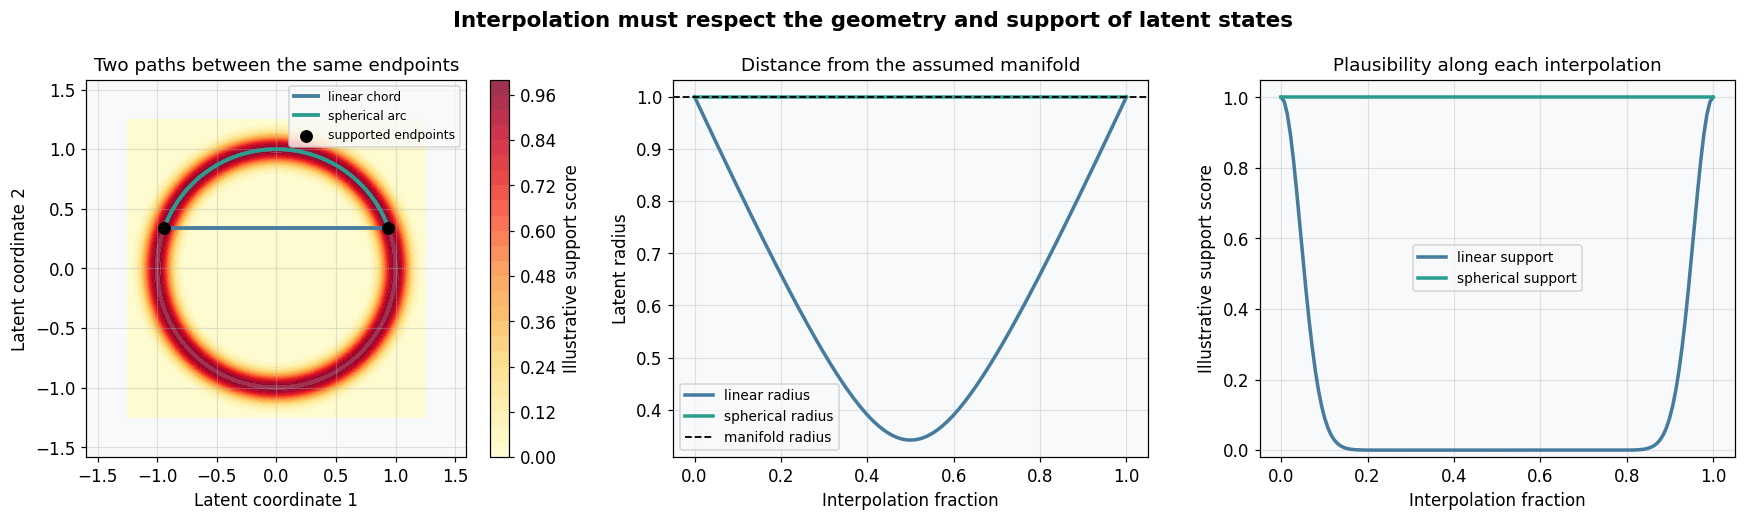

In [7]:
np.random.seed(6)
start_angle = np.deg2rad(20.0)
end_angle = np.deg2rad(160.0)
start = np.array([np.cos(start_angle), np.sin(start_angle)])
end = np.array([np.cos(end_angle), np.sin(end_angle)])
alpha = np.linspace(0.0, 1.0, 140)
linear_path = (1.0 - alpha[:, None]) * start + alpha[:, None] * end

theta = np.arccos(np.clip(start @ end, -1.0, 1.0))
spherical_path = (
    np.sin((1.0 - alpha) * theta)[:, None] / np.sin(theta) * start
    + np.sin(alpha * theta)[:, None] / np.sin(theta) * end
)

linear_radius = np.linalg.norm(linear_path, axis=1)
spherical_radius = np.linalg.norm(spherical_path, axis=1)
linear_support = np.exp(-0.5 * ((linear_radius - 1.0) / 0.08) ** 2)
spherical_support = np.exp(-0.5 * ((spherical_radius - 1.0) / 0.08) ** 2)

grid = np.linspace(-1.25, 1.25, 300)
grid_x, grid_y = np.meshgrid(grid, grid)
grid_radius = np.sqrt(grid_x**2 + grid_y**2)
support_field = np.exp(-0.5 * ((grid_radius - 1.0) / 0.08) ** 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
fig.suptitle('Interpolation must respect the geometry and support of latent states', fontsize=14, fontweight='bold')

contour = axes[0].contourf(grid_x, grid_y, support_field, levels=30, cmap='YlOrRd', alpha=0.8)
axes[0].plot(linear_path[:, 0], linear_path[:, 1], color='#457b9d', linewidth=2.5, label='linear chord')
axes[0].plot(spherical_path[:, 0], spherical_path[:, 1], color='#2a9d8f', linewidth=2.5, label='spherical arc')
axes[0].scatter([start[0], end[0]], [start[1], end[1]], color='black', s=55, zorder=4, label='supported endpoints')
axes[0].set_title('Two paths between the same endpoints')
axes[0].set_xlabel('Latent coordinate 1')
axes[0].set_ylabel('Latent coordinate 2')
axes[0].axis('equal')
axes[0].legend(fontsize=8)
colorbar = fig.colorbar(contour, ax=axes[0])
colorbar.set_label('Illustrative support score')

axes[1].plot(alpha, linear_radius, color='#457b9d', linewidth=2.3, label='linear radius')
axes[1].plot(alpha, spherical_radius, color='#2a9d8f', linewidth=2.3, label='spherical radius')
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='manifold radius')
axes[1].set_title('Distance from the assumed manifold')
axes[1].set_xlabel('Interpolation fraction')
axes[1].set_ylabel('Latent radius')
axes[1].legend(fontsize=9)

axes[2].plot(alpha, linear_support, color='#457b9d', linewidth=2.3, label='linear support')
axes[2].plot(alpha, spherical_support, color='#2a9d8f', linewidth=2.3, label='spherical support')
axes[2].set_title('Plausibility along each interpolation')
axes[2].set_xlabel('Interpolation fraction')
axes[2].set_ylabel('Illustrative support score')
axes[2].set_ylim(-0.02, 1.05)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** Linear interpolation cuts through the interior of the circle, where the illustrative support score collapses. Spherical interpolation follows the supported arc and keeps unit radius throughout.
2. **Why it looks this way:** Euclidean lerp optimizes coordinate straightness, not density, decoder distortion, or dynamic feasibility. A geometry-aware path uses the structure of the latent manifold instead.
3. **Key takeaway:** Interpolation is a modeling choice, not neutral plumbing. Even a geodesic can violate dynamics, so geometric support and action feasibility should be checked separately.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Paths versus endpoints | Temporal order and visited regions contain information that endpoints cannot recover. |
| 2. Irregular timestamps | Derivatives and resampling require real time gaps and provenance. |
| 3. Smoothing trade-offs | Denoising assumptions can bias or erase genuine discontinuities. |
| 4. Changepoint segmentation | Boundary selection balances within-segment fit against model complexity. |
| 5. Temporal alignment | DTW removes speed variation but changes the invariance encoded by similarity. |
| 6. Interpolation geometry | Straight coordinate paths can leave latent support even when endpoints are valid. |

### Connection to Latent-Anything

`Trajectory` should be a first-class primitive containing timestamps, masks, edge-aligned actions, uncertainty, source, frame, and model version. Operations such as `resample`, `smooth`, `segment`, `align`, and `interpolate` should require explicit methods and return provenance so edited or inferred states are never confused with observed posterior states.